# BÀI TẬP: MEDICAL INSURANCE COST
**Nguồn:** kaggle.com/datasets/mosapabdelghany/medical-insurance-cost-dataset



## Setup

In [1]:

import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from scipy import stats
sns.set_style('whitegrid')
csv_path = 'https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv'

df = pd.read_csv(csv_path)
print('Loaded from:', csv_path)
df.head()

Loaded from: https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


---
# PHẦN A — DATA PROFILING
## A.1. Data size, column names, data types

In [2]:
# TODO
print(df.size)
df.info()

9366
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


## A.2. Missing values & Duplicate data

In [3]:
# TODO
print(df.isnull().sum())
print(df.duplicated().sum())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64
1


## A.3. Invalid values

In [4]:
# TODO
df.describe()
print('Age range:', df['age'].min(), '-', df['age'].max())
print('BMI range:', df['bmi'].min(), '-', df['bmi'].max())
print('Charges min:', df['charges'].min())
print('Children range:', df['children'].min(), '-', df['children'].max())
print(df['sex'].unique())
print(df['smoker'].unique())
print(df['region'].unique())

Age range: 18 - 64
BMI range: 15.96 - 53.13
Charges min: 1121.8739
Children range: 0 - 5
['female' 'male']
['yes' 'no']
['southwest' 'southeast' 'northwest' 'northeast']


## A.4. Create a new column
Tạo cột `bmi_group`: Normal (<25), Overweight (25-30), Obese (>=30).

In [5]:

# TODO
df["bmi_group"] = np.select(
    [df["bmi"] < 25, df["bmi"] < 30],
    ["Normal", "Overweight"],
    default="Obese"
)

---
# PHẦN B — DESCRIPTIVE STATISTICS
## Group 1 — Central Tendency

In [6]:
# TODO
for col in ['age', 'bmi', 'children', 'charges']:
    print(f"{col:10s} | mean: {df[col].mean():.2f} | median: {df[col].median():.2f} | mode: {df[col].mode()[0]}")

age        | mean: 39.21 | median: 39.00 | mode: 18
bmi        | mean: 30.66 | median: 30.40 | mode: 32.3
children   | mean: 1.09 | median: 1.00 | mode: 0
charges    | mean: 13270.42 | median: 9382.03 | mode: 1639.5631


## Group 2 — Dispersion

In [7]:
# TODO
for col in ['age', 'bmi', 'charges']:
    print(f"{col:10s} | std: {df[col].std():.2f} | var: {df[col].var():.2f} | "
          f"range: {df[col].max()-df[col].min():.2f} | IQR: {df[col].quantile(0.75)-df[col].quantile(0.25):.2f}")

age        | std: 14.05 | var: 197.40 | range: 46.00 | IQR: 24.00
bmi        | std: 6.10 | var: 37.19 | range: 37.17 | IQR: 8.40
charges    | std: 12110.01 | var: 146652372.15 | range: 62648.55 | IQR: 11899.63


## Group 3 — Location and Shape

age        | skew: 0.06 | kurtosis: -1.25
0.25    27.0
0.50    39.0
0.75    51.0
Name: age, dtype: float64

bmi        | skew: 0.28 | kurtosis: -0.05
0.25    26.29625
0.50    30.40000
0.75    34.69375
Name: bmi, dtype: float64

charges    | skew: 1.52 | kurtosis: 1.61
0.25     4740.287150
0.50     9382.033000
0.75    16639.912515
Name: charges, dtype: float64



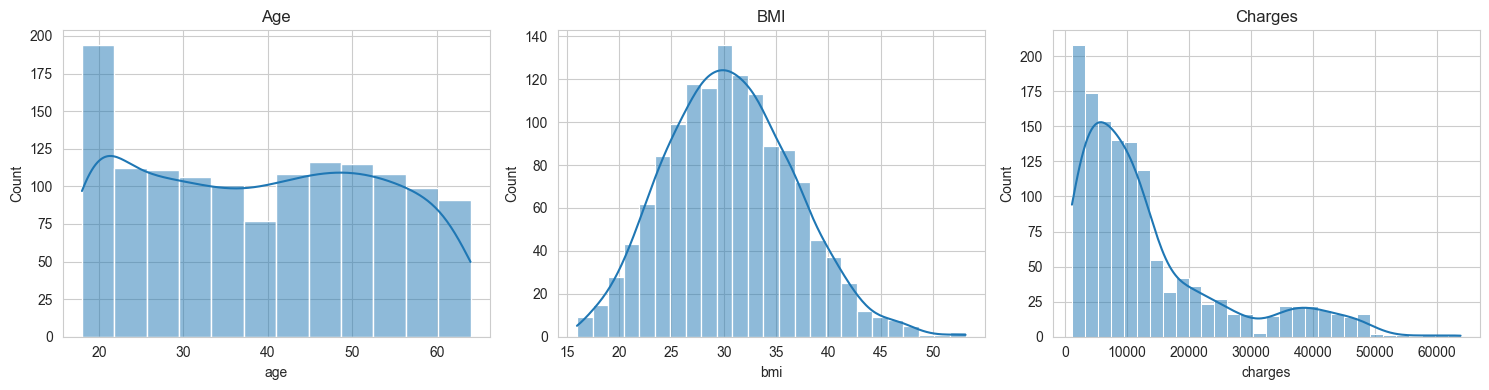

In [8]:
# TODO
for col in ['age', 'bmi', 'charges']:
    print(f"{col:10s} | skew: {df[col].skew():.2f} | kurtosis: {df[col].kurt():.2f}")
    print(df[col].quantile([0.25, 0.5, 0.75]))
    print()

fig, axes = plt.subplots(1, 3, figsize=(15,4))
sns.histplot(df['age'], kde=True, ax=axes[0]).set_title('Age')
sns.histplot(df['bmi'], kde=True, ax=axes[1]).set_title('BMI')
sns.histplot(df['charges'], kde=True, ax=axes[2]).set_title('Charges')
plt.tight_layout(); plt.show()

---
# PHẦN C — DEFINE THE QUESTION

## Câu hỏi 1: Người hút thuốc trả chi phí cao hơn bao nhiêu lần so với người không hút, và có đồng đều giữa các vùng không?

Tỷ lệ chênh lệch 3.800001458298319
tỷ lệ chênh lẹch giữa các vùng region
northeast    3.237514
northwest    3.528561
southeast    4.338155
southwest    4.023933
Name: charges, dtype: float64


<Axes: xlabel='region', ylabel='charges'>

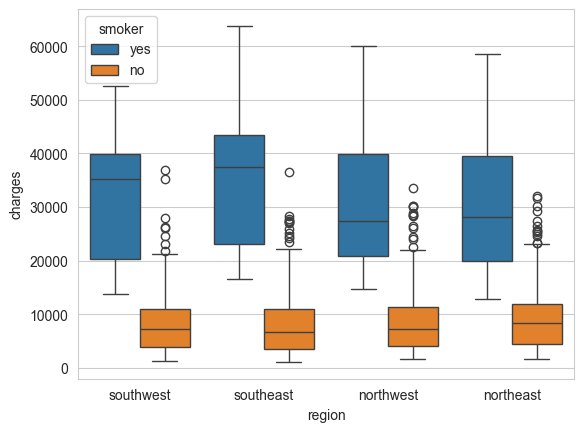

In [9]:
# TODO
smoker =df.groupby('smoker')['charges'].mean()
print("Tỷ lệ chênh lệch",smoker["yes"]/smoker["no"])
rsmoker=df.groupby(['smoker', 'region'])['charges'].mean()
print("tỷ lệ chênh lẹch giữa các vùng",rsmoker['yes']/rsmoker['no'])
sns.boxplot(x='region', y='charges',hue='smoker', data=df)

## Câu hỏi 2: BMI có tương quan với chi phí mạnh hơn ở nhóm hút thuốc hay không hút thuốc?

Corr (smoker): 0.8064806070155407
Corr (non-smoker): 0.08403654312833286


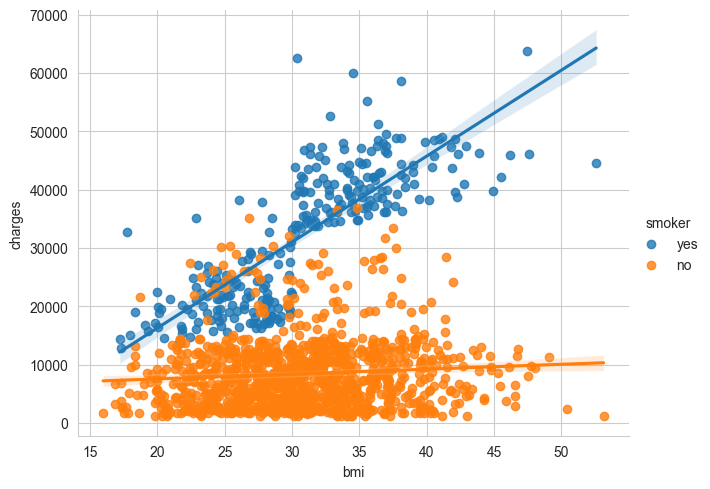

In [10]:
# TODO
corr_smoker = df[df['smoker']=='yes'][['bmi','charges']].corr().iloc[0,1]
corr_nonsmoker = df[df['smoker']=='no'][['bmi','charges']].corr().iloc[0,1]
print('Corr (smoker):', corr_smoker)
print('Corr (non-smoker):', corr_nonsmoker)

sns.lmplot(x='bmi', y='charges', hue='smoker', data=df, height=5, aspect=1.3)

## Câu hỏi 3: Vùng nào có chi phí bảo hiểm trung bình cao nhất?

region
southeast    14735.411438
northeast    13406.384516
northwest    12417.575374
southwest    12346.937377
Name: charges, dtype: float64


<Axes: xlabel='region', ylabel='charges'>

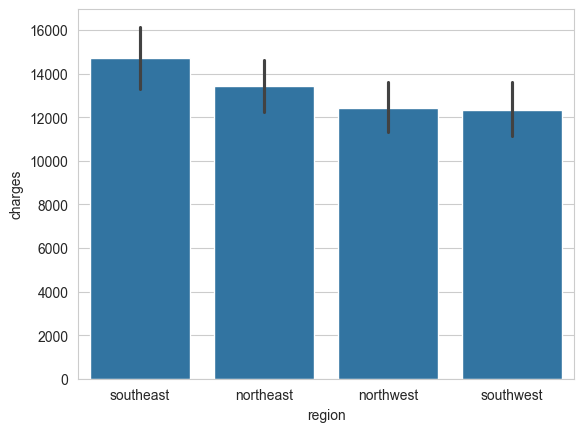

In [11]:
region_mean = df.groupby('region')['charges'].mean().sort_values(ascending=False)
print(region_mean)
sns.barplot(x='region', y='charges', data=df, order=region_mean.index)

## Câu hỏi 4: Số lượng con cái có làm tăng chi phí bảo hiểm không?

children
0    12365.975602
1    12731.171832
2    15073.563734
3    15355.318367
4    13850.656311
5     8786.035247
Name: charges, dtype: float64
Correlation children vs charges: 0.06799822684790487


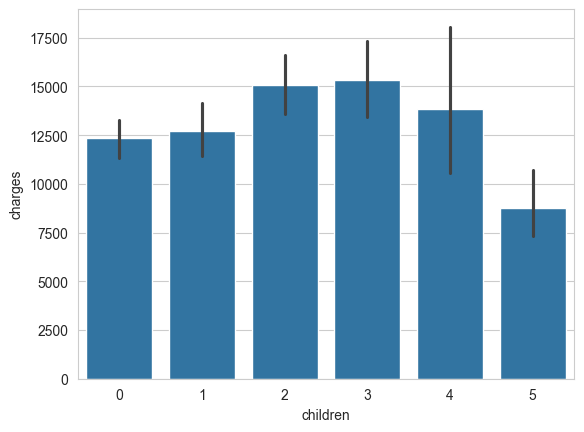

In [12]:
# TODO
print(df.groupby('children')['charges'].mean())
sns.barplot(x='children', y='charges', data=df)
print('Correlation children vs charges:', df['children'].corr(df['charges']))

## Câu hỏi 5: Tuổi có tương quan với chi phí bảo hiểm không?

Correlation age vs charges: 0.29900819333064776


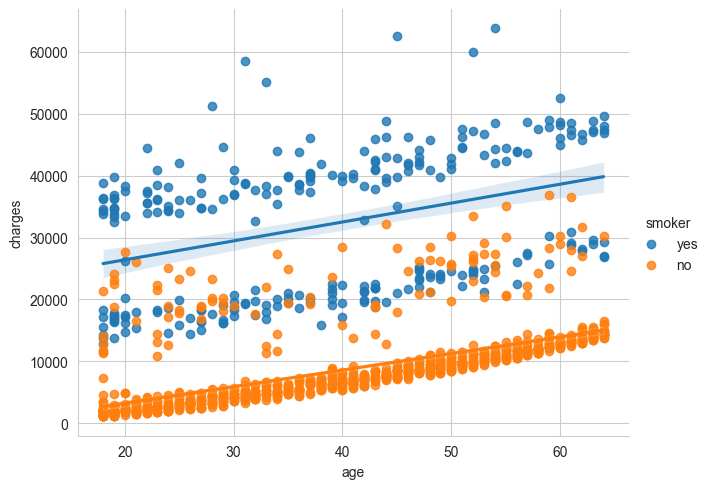

In [13]:
# TODO
print('Correlation age vs charges:', df['age'].corr(df['charges']))
sns.lmplot(x='age', y='charges', hue='smoker', data=df, height=5, aspect=1.3)

## Câu hỏi 6 (Tổng hợp) — Viết insight tổng hợp
Dựa trên Phần A, B, C, viết 4-5 câu insight tổng thể.

Dữ liệu sạch, không thiếu, không trùng
charges lệch phải mạnh, phần lớn hợp đồng chi phí thấp nhưng có nhóm chi phí rất cao.
Hút thuốc là yếu tố ảnh hưởng chi phí mạnh nhất — chênh lệch trung bình gấp nhiều lần so với không hút, và hiệu ứng này còn được khuếch đại bởi BMI cao.
Tuổi có tương quan dương với chi phí nhưng yếu hơn nhiều so với smoker; số con hầu như không ảnh hưởng.
Vùng địa lý có chênh lệch chi phí nhưng không lớn bằng yếu tố hành vi (hút thuốc, BMI).